# 11 Compare Main Results DIBaS (3 CNN Seeds)

This notebook collects the six saved experiment outputs for DIBaS and builds the patch-level comparison tables and figures.


In [1]:
from pathlib import Path
import csv
import json
import shutil

import matplotlib.pyplot as plt

import pandas as pd

from IPython.display import display

# This helper keeps the notebook easy to run from the repo root or from notebooks/.
def find_repo_root(start_path: Path) -> Path:
    if (start_path / "raw_data").exists():
        return start_path
    if start_path.name == "notebooks" and (start_path.parent / "raw_data").exists():
        return start_path.parent
    raise FileNotFoundError("Could not find the FYP2 repo root.")

REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results"
NOTEBOOK_TAG = "11_compare_main_results_dibas"
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / NOTEBOOK_TAG
NOTEBOOK_FIGURES_DIR = NOTEBOOK_RESULTS_DIR / "figures"

# Compare notebooks are quick to rebuild, so clear only this notebook's old comparison outputs.
if NOTEBOOK_RESULTS_DIR.exists():
    shutil.rmtree(NOTEBOOK_RESULTS_DIR)
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_TAGS = ["05_resnet50_baseline_dibas", "06_resnet50_gan_dibas", "07_efficientnetv2s_baseline_dibas", "08_efficientnetv2s_gan_dibas", "09_convnextv2nano_baseline_dibas", "10_convnextv2nano_gan_dibas"]

In [2]:
# This helper reads a CSV file into a plain list of rows.
def read_csv_rows(csv_path: Path):
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

# This helper writes a CSV file with a stable header.
def write_csv_rows(csv_path: Path, rows, fieldnames):
    if not rows:
        raise ValueError(f"No rows were provided for {csv_path.name}.")
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    with csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

# This helper writes one small JSON file with clean formatting.
def write_json(json_path: Path, data):
    json_path.parent.mkdir(parents=True, exist_ok=True)
    json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")

,run_tag,model_name,model_display_name,training_mode,seed_count,fold_count,run_count,mean_accuracy,std_accuracy,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_precision,std_macro_precision,mean_macro_recall,std_macro_recall,mean_macro_f1,std_macro_f1
0,05_resnet50_baseline_dibas,resnet50,ResNet-50,baseline,3,5,15,0.990858,0.005960,0.990118,0.007422,0.991155,0.004776,0.990118,0.007422,0.990553,0.006217
1,06_resnet50_gan_dibas,resnet50,ResNet-50,gan,3,5,15,0.994551,0.002009,0.994270,0.002446,0.994509,0.001748,0.994270,0.002446,0.994381,0.002077
2,07_efficientnetv2s_baseline_dibas,efficientnetv2s,EfficientNetV2-S,baseline,3,5,15,0.995126,0.002448,0.995139,0.002186,0.994844,0.002874,0.995139,0.002186,0.994979,0.002514
3,08_efficientnetv2s_gan_dibas,efficientnetv2s,EfficientNetV2-S,gan,3,5,15,0.995796,0.001556,0.995681,0.001541,0.995673,0.001794,0.995681,0.001541,0.995668,0.001601
4,09_convnextv2nano_baseline_dibas,convnextv2nano,ConvNeXtV2-Nano,baseline,3,5,15,0.989645,0.009794,0.989522,0.008354,0.989505,0.010761,0.989522,0.008354,0.989359,0.009945
5,10_convnextv2nano_gan_dibas,convnextv2nano,ConvNeXtV2-Nano,gan,3,5,15,0.990038,0.004579,0.989468,0.005544,0.990090,0.004057,0.989468,0.005544,0.989720,0.004756


,class_name,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1,run_tag
0,cocci,0.992119,0.006334,0.985828,0.016749,0.98886,0.007485,05_resnet50_baseline_dibas
1,bacilli,0.99019,0.011296,0.994408,0.004541,0.992246,0.004951,05_resnet50_baseline_dibas
2,cocci,0.994189,0.002433,0.992644,0.00539,0.993405,0.002454,06_resnet50_gan_dibas
3,bacilli,0.994829,0.003752,0.995897,0.001733,0.995357,0.001701,06_resnet50_gan_dibas
4,cocci,0.993063,0.006214,0.995216,0.00311,0.994124,0.002922,07_efficientnetv2s_baseline_dibas
5,bacilli,0.996626,0.002183,0.995062,0.004497,0.995835,0.002106,07_efficientnetv2s_baseline_dibas
6,cocci,0.994858,0.00439,0.99501,0.003513,0.994922,0.001872,08_efficientnetv2s_gan_dibas
7,bacilli,0.996487,0.002454,0.996351,0.003142,0.996413,0.001331,08_efficientnetv2s_gan_dibas
8,cocci,0.986844,0.023375,0.988812,0.008855,0.987632,0.011181,09_convnextv2nano_baseline_dibas
9,bacilli,0.992166,0.006119,0.990232,0.018287,0.991086,0.008711,09_convnextv2nano_baseline_dibas


,model_name,accuracy_gain,balanced_accuracy_gain,macro_precision_gain,macro_recall_gain,macro_f1_gain
0,convnextv2nano,0.000393,-0.000054,0.000585,-0.000054,0.000361
1,efficientnetv2s,0.000670,0.000542,0.000829,0.000542,0.000689
2,resnet50,0.003693,0.004152,0.003354,0.004152,0.003828


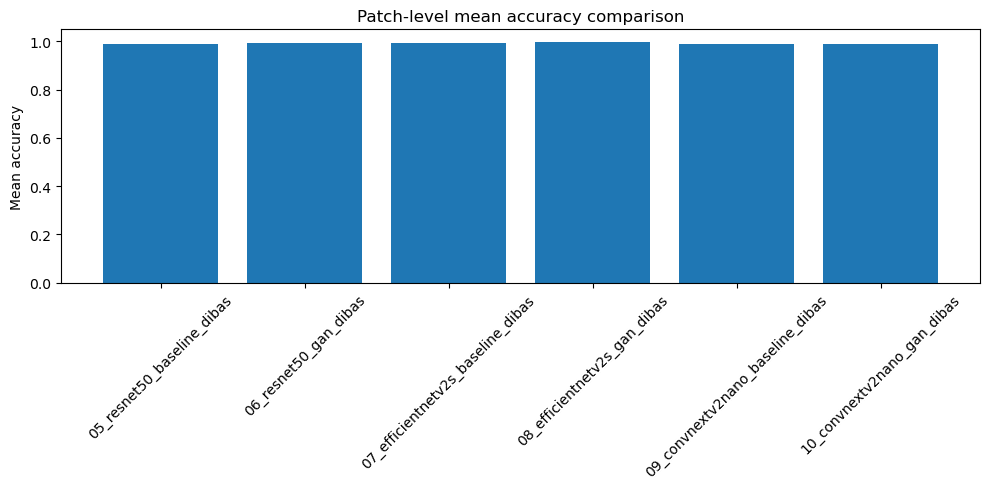

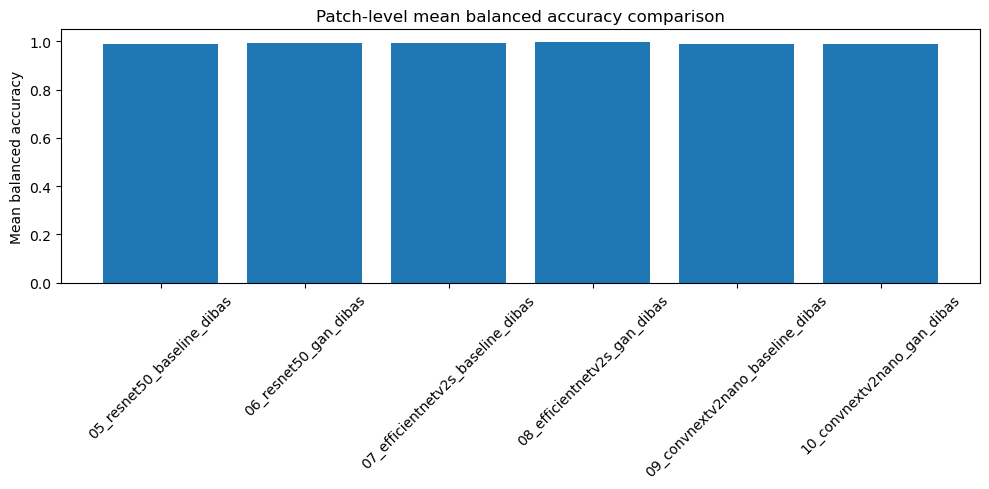

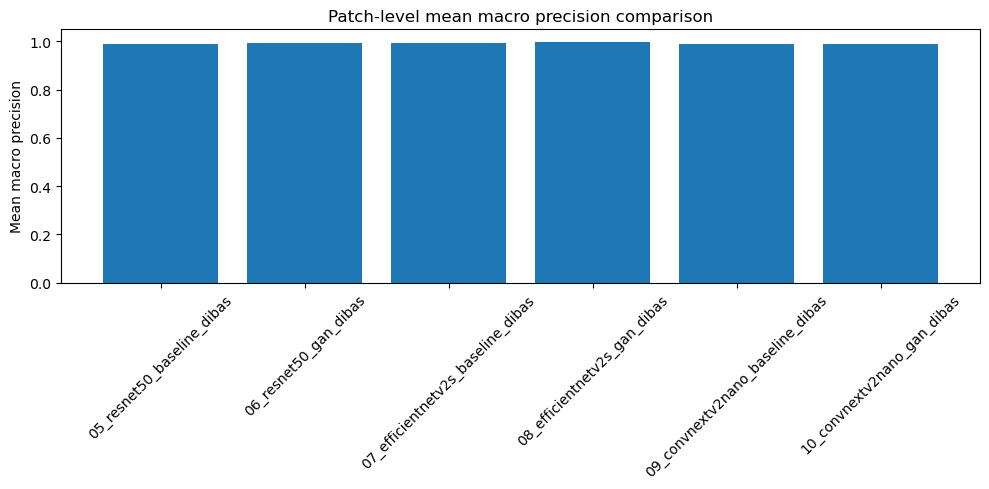

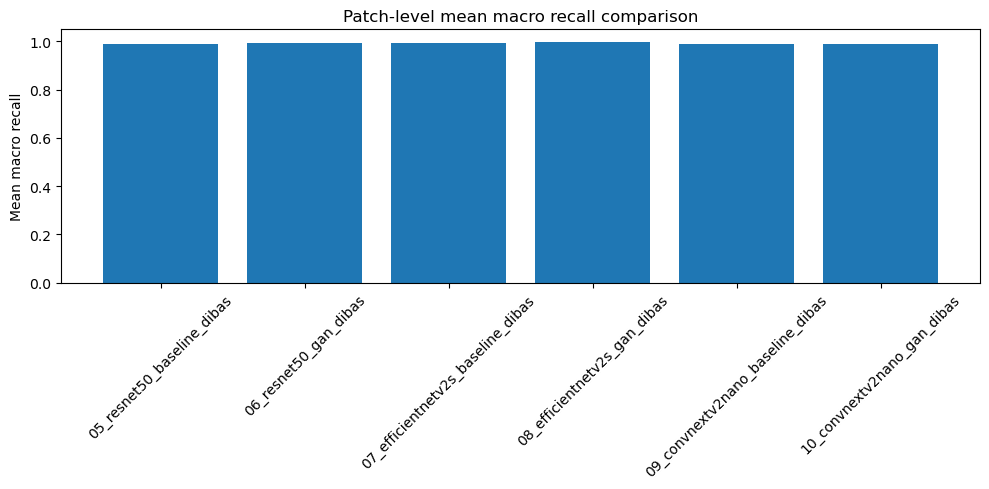

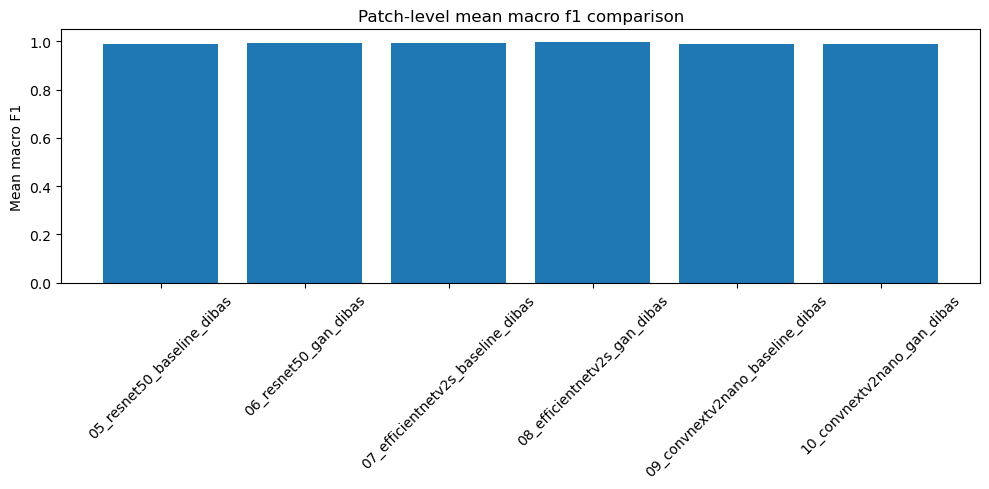

,run_tag,class_name,metric_name,metric_value
0,05_resnet50_baseline_dibas,cocci,precision,0.992119
1,05_resnet50_baseline_dibas,cocci,recall,0.985828
2,05_resnet50_baseline_dibas,cocci,f1,0.988860
3,05_resnet50_baseline_dibas,bacilli,precision,0.990190
4,05_resnet50_baseline_dibas,bacilli,recall,0.994408
5,05_resnet50_baseline_dibas,bacilli,f1,0.992246
6,06_resnet50_gan_dibas,cocci,precision,0.994189
7,06_resnet50_gan_dibas,cocci,recall,0.992644
8,06_resnet50_gan_dibas,cocci,f1,0.993405
9,06_resnet50_gan_dibas,bacilli,precision,0.994829


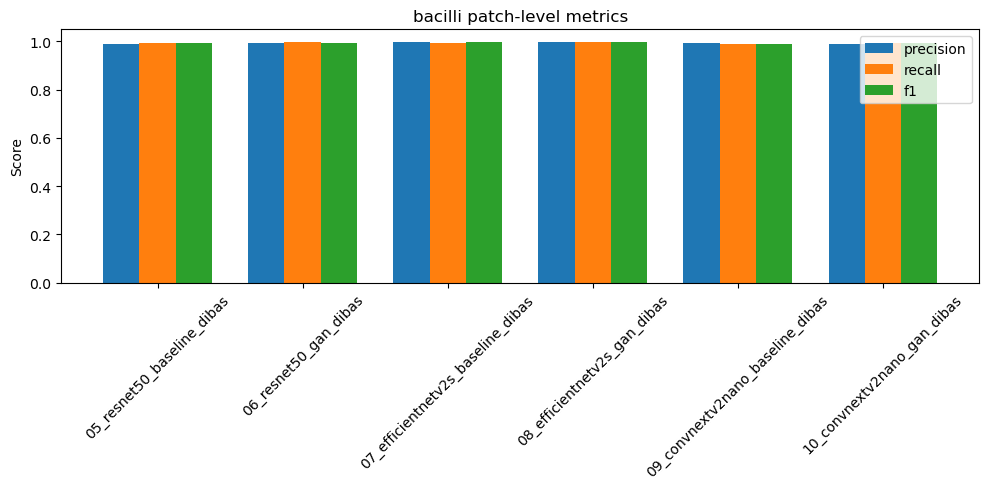

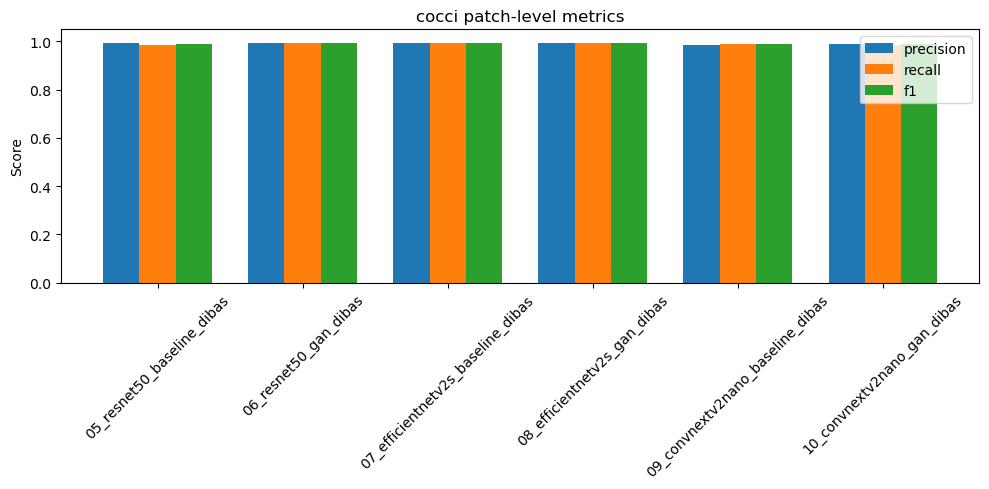

In [3]:
# We read the saved outputs from the six experiment notebooks.
model_rows = []
class_rows = []
round_rows = []

for run_tag in RUN_TAGS:
    summary_path = RESULTS_DIR / run_tag / "summary.json"
    class_metrics_path = RESULTS_DIR / run_tag / "class_metrics_mean.csv"
    round_metrics_path = RESULTS_DIR / run_tag / "round_metrics.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary for {run_tag}: {summary_path}")

    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    model_rows.append({
        "run_tag": run_tag,
        "model_name": summary["model_name"],
        "model_display_name": summary["model_display_name"],
        "training_mode": summary["training_mode"],
        "seed_count": summary.get("seed_count", ""),
        "fold_count": summary.get("fold_count", ""),
        "run_count": summary.get("run_count", ""),
        "mean_accuracy": summary["mean_accuracy"],
        "std_accuracy": summary["std_accuracy"],
        "mean_balanced_accuracy": summary["mean_balanced_accuracy"],
        "std_balanced_accuracy": summary["std_balanced_accuracy"],
        "mean_macro_precision": summary["mean_macro_precision"],
        "std_macro_precision": summary["std_macro_precision"],
        "mean_macro_recall": summary["mean_macro_recall"],
        "std_macro_recall": summary["std_macro_recall"],
        "mean_macro_f1": summary["mean_macro_f1"],
        "std_macro_f1": summary["std_macro_f1"],
    })

    for row in read_csv_rows(class_metrics_path):
        row["run_tag"] = run_tag
        class_rows.append(row)

    for row in read_csv_rows(round_metrics_path):
        row["run_tag"] = run_tag
        round_rows.append(row)

write_csv_rows(NOTEBOOK_RESULTS_DIR / "model_comparison.csv", model_rows, list(model_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "class_comparison.csv", class_rows, list(class_rows[0].keys()))
write_csv_rows(NOTEBOOK_RESULTS_DIR / "per_round_metrics.csv", round_rows, list(round_rows[0].keys()))

backbone_lookup = {}
for row in model_rows:
    model_name = row["model_name"]
    if model_name not in backbone_lookup:
        backbone_lookup[model_name] = {}
    backbone_lookup[model_name][row["training_mode"]] = row
gain_rows = []
for model_name in sorted(backbone_lookup):
    if "baseline" in backbone_lookup[model_name] and "gan" in backbone_lookup[model_name]:
        baseline = backbone_lookup[model_name]["baseline"]
        gan = backbone_lookup[model_name]["gan"]
        gain_rows.append({
            "model_name": model_name,
            "accuracy_gain": round(float(gan["mean_accuracy"]) - float(baseline["mean_accuracy"]), 6),
            "balanced_accuracy_gain": round(float(gan["mean_balanced_accuracy"]) - float(baseline["mean_balanced_accuracy"]), 6),
            "macro_precision_gain": round(float(gan["mean_macro_precision"]) - float(baseline["mean_macro_precision"]), 6),
            "macro_recall_gain": round(float(gan["mean_macro_recall"]) - float(baseline["mean_macro_recall"]), 6),
            "macro_f1_gain": round(float(gan["mean_macro_f1"]) - float(baseline["mean_macro_f1"]), 6),
        })

write_csv_rows(NOTEBOOK_RESULTS_DIR / "gain_summary.csv", gain_rows, list(gain_rows[0].keys()))
write_json(NOTEBOOK_RESULTS_DIR / "summary.json", {"notebook_tag": NOTEBOOK_TAG, "run_tags": RUN_TAGS})

model_df = pd.DataFrame(model_rows)
class_df = pd.DataFrame(class_rows)
gain_df = pd.DataFrame(gain_rows)
display(model_df)
display(class_df)
display(gain_df)

# These figures are shown in the notebook and saved to disk.
metric_plot_specs = [
    ("mean_accuracy", "accuracy_comparison.png", "Mean accuracy"),
    ("mean_balanced_accuracy", "balanced_accuracy_comparison.png", "Mean balanced accuracy"),
    ("mean_macro_precision", "macro_precision_comparison.png", "Mean macro precision"),
    ("mean_macro_recall", "macro_recall_comparison.png", "Mean macro recall"),
    ("mean_macro_f1", "macro_f1_comparison.png", "Mean macro F1"),
]
for metric_name, file_name, axis_label in metric_plot_specs:
    fig, axis = plt.subplots(figsize=(10, 5))
    axis.bar(model_df["run_tag"], model_df[metric_name])
    axis.set_ylim(0.0, 1.05)
    axis.set_ylabel(axis_label)
    axis.set_title(f"Patch-level {axis_label.lower()} comparison")
    axis.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(NOTEBOOK_FIGURES_DIR / file_name, dpi=200)
    plt.show()

class_plot_rows = []
for _, row in class_df.iterrows():
    class_plot_rows.append({
        "run_tag": row["run_tag"],
        "class_name": row["class_name"],
        "metric_name": "precision",
        "metric_value": float(row["mean_precision"]),
    })
    class_plot_rows.append({
        "run_tag": row["run_tag"],
        "class_name": row["class_name"],
        "metric_name": "recall",
        "metric_value": float(row["mean_recall"]),
    })
    class_plot_rows.append({
        "run_tag": row["run_tag"],
        "class_name": row["class_name"],
        "metric_name": "f1",
        "metric_value": float(row["mean_f1"]),
    })
    
class_plot_df = pd.DataFrame(class_plot_rows)
display(class_plot_df)
for class_name in sorted(class_plot_df["class_name"].unique()):
    current = class_plot_df[class_plot_df["class_name"] == class_name]
    pivot_df = current.pivot(index="run_tag", columns="metric_name", values="metric_value").reset_index()
    fig, axis = plt.subplots(figsize=(10, 5))
    x_positions = range(len(pivot_df))
    metric_names = ["precision", "recall", "f1"]
    bar_width = 0.25
    for metric_index, metric_name in enumerate(metric_names):
        offsets = [position + ((metric_index - 1) * bar_width) for position in x_positions]
        axis.bar(offsets, pivot_df[metric_name], width=bar_width, label=metric_name)
    axis.set_xticks(list(x_positions))
    axis.set_xticklabels(pivot_df["run_tag"], rotation=45)
    axis.set_ylim(0.0, 1.05)
    axis.set_ylabel("Score")
    axis.set_title(f"{class_name} patch-level metrics")
    axis.legend()
    fig.tight_layout()
    fig.savefig(NOTEBOOK_FIGURES_DIR / f"{class_name}_class_metrics.png", dpi=200)
    plt.show()